# Judged-only embedding spread experiment for RAG diversity

This notebook is built for the experiment you described:

- **only use judged documents**
- keep the **same dense / hybrid MMR / dual residual retrieval code** as the original notebook
- compute embedding-space spread statistics
- optionally visualize the geometry for selected queries

## What is different from the original notebook?

The original notebook used `docs_store()` from `ir_datasets`, which can trigger access to the full MS MARCO passage collection.

This notebook **does not do that**.

Instead it:

1. loads **queries + qrels** from TREC-DL 2019/2020
2. builds the union of **judged doc_ids**
3. reads **only those judged passages** from a local `collection.tsv` by streaming line-by-line and caching the result
4. runs dense / MMR / dual residual **inside that judged-only candidate set**
5. computes embedding-space spread metrics and visualizations

## Important note

To get passage text, this notebook needs **some source of MS MARCO passage text**.
The intended fast path is:

- point `COLLECTION_TSV` to a local MS MARCO `collection.tsv`, or
- use the cached file `rag_diversity_cache/judged_passages.tsv` if already built

So this notebook avoids **loading the full corpus into the experiment**, but it still needs a local text source once in order to extract the judged passages.

In [2]:
# %pip install -q ir_datasets sentence-transformers rank_bm25 scikit-learn pandas matplotlib tqdm

In [3]:
import json
import math
import os
import random
import re
from collections import Counter, defaultdict
from itertools import product
from typing import Dict, List, Optional

import ir_datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASETS = [
    "msmarco-passage/trec-dl-2019",
    "msmarco-passage/trec-dl-2020",
]

CACHE_DIR = "rag_diversity_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K = 10

# Retrieval defaults
DEFAULT_ALPHA = 0.75
DEFAULT_LAMBDA = 0.30
DEFAULT_ETA = 0.35

# Dual residual defaults
DEFAULT_BETA_STOP = 0.50
DEFAULT_MIN_COMBINED_RESIDUAL_FRAC = 0.10
DEFAULT_MIN_COMBINED_SCORE = 0.10

MAX_CANDIDATE_DOCS = None

JUDGED_PASSAGES_CACHE_TSV = os.path.join(CACHE_DIR, "judged_passages.tsv")

# Set this manually if needed.
# Example:
# COLLECTION_TSV = "/home/users/<SUNET>/.ir_datasets/msmarco-passage/collection.tsv"
COLLECTION_TSV = os.environ.get("MSMARCO_COLLECTION_TSV", "")

print("Cache directory:", CACHE_DIR)
print("Judged passages cache:", JUDGED_PASSAGES_CACHE_TSV)
print("COLLECTION_TSV:", COLLECTION_TSV if COLLECTION_TSV else "<not set>")

Cache directory: rag_diversity_cache
Judged passages cache: rag_diversity_cache/judged_passages.tsv
COLLECTION_TSV: <not set>


## Load TREC-DL queries and graded judgments

This part is still the same basic setup as the original notebook.
We use `ir_datasets` for the **TREC-DL queries and qrels**, which are small.

In [5]:
datasets = [ir_datasets.load(name) for name in DATASETS]
datasets

[Dataset(id='msmarco-passage/trec-dl-2019', provides=['docs', 'queries', 'qrels', 'scoreddocs']),
 Dataset(id='msmarco-passage/trec-dl-2020', provides=['docs', 'queries', 'qrels', 'scoreddocs'])]

In [6]:
def load_queries_and_qrels(dataset):
    queries = {q.query_id: q.text for q in dataset.queries_iter()}
    qrels = defaultdict(dict)
    for qr in dataset.qrels_iter():
        qrels[qr.query_id][qr.doc_id] = qr.relevance
    return queries, dict(qrels)

all_queries = {}
all_qrels = {}
for ds in datasets:
    q, r = load_queries_and_qrels(ds)
    all_queries.update(q)
    all_qrels.update(r)

sample_qid = sorted(all_qrels.keys())[0]
print("Sample query id:", sample_qid)
print("Sample query text:", all_queries[sample_qid])
print("Sample qrels:", all_qrels[sample_qid])

Sample query id: 1030303
Sample query text: who is aziz hashim
Sample qrels: {'1038342': 0, '1042969': 0, '1044043': 0, '1056584': 0, '1070133': 0, '1070134': 0, '1086238': 0, '1104408': 0, '1161432': 0, '1161439': 0, '1166176': 0, '1172906': 0, '1207443': 0, '1227100': 0, '1269099': 0, '1292821': 0, '1292822': 0, '1305520': 0, '1305521': 0, '1305528': 0, '1358683': 0, '1369019': 0, '1376556': 0, '1376558': 0, '1397758': 0, '1402779': 0, '1451846': 0, '1451848': 0, '1451850': 0, '1451851': 0, '1462522': 0, '1492373': 0, '1538148': 0, '1538153': 0, '163871': 0, '1666520': 0, '1777312': 0, '1784767': 0, '1811800': 0, '1813557': 0, '1813561': 0, '1905988': 0, '196026': 0, '2001450': 0, '2057929': 0, '2146415': 0, '2194939': 0, '2205078': 0, '2217415': 0, '2217635': 0, '22484': 0, '226464': 0, '2484376': 0, '2488127': 0, '2563261': 0, '2597066': 0, '2620119': 0, '2628843': 0, '2628844': 0, '2712400': 0, '2740876': 0, '2782702': 0, '288491': 0, '292060': 0, '309441': 0, '3105375': 0, '31410

In [7]:
def build_frozen_query_set(queries: Dict[str, str], qrels: Dict[str, Dict[str, int]]):
    queries_frozen = {}
    qrels_frozen = {}
    for qid, text in queries.items():
        judged = qrels.get(qid, {})
        if any(rel > 0 for rel in judged.values()):
            queries_frozen[qid] = text
            qrels_frozen[qid] = judged
    return queries_frozen, qrels_frozen

queries_frozen, qrels_frozen = build_frozen_query_set(all_queries, all_qrels)
print("Frozen query count:", len(queries_frozen))
print("Example query id:", next(iter(queries_frozen)))

Frozen query count: 97
Example query id: 156493


In [8]:
candidate_doc_ids = sorted({doc_id for qid in qrels_frozen for doc_id in qrels_frozen[qid]})
if MAX_CANDIDATE_DOCS is not None:
    candidate_doc_ids = candidate_doc_ids[:MAX_CANDIDATE_DOCS]

print("Unique judged candidate docs:", len(candidate_doc_ids))

Unique judged candidate docs: 20349


## Load only the judged passages

This is the main change.

We do **not** call `docs_store()`.

Instead:

- if a small cached file of judged passages already exists, load it
- otherwise scan a local `collection.tsv` **line by line**
- keep only doc_ids that are in the judged candidate set
- write those passages to a small cache file for future runs

That means the experiment itself only works with the judged documents.

In [9]:
def find_collection_tsv(initial_path: str = "") -> Optional[str]:
    candidates = []
    if initial_path:
        candidates.append(initial_path)

    home = os.path.expanduser("~")
    candidates.extend([
        os.path.join(home, ".ir_datasets", "msmarco-passage", "collection.tsv"),
        os.path.join(home, ".ir_datasets", "downloads", "collection.tsv"),
        os.path.join(home, ".ir_datasets", "downloads", "msmarco-passage", "collection.tsv"),
        os.path.join(home, ".ir_datasets", "downloads", "collectionandqueries", "collection.tsv"),
    ])

    for path in candidates:
        if path and os.path.exists(path):
            return path

    # Last-resort recursive search inside ~/.ir_datasets
    search_root = os.path.join(home, ".ir_datasets")
    if os.path.exists(search_root):
        for root, _, files in os.walk(search_root):
            if "collection.tsv" in files:
                return os.path.join(root, "collection.tsv")

    return None

def load_judged_passages_from_cache(cache_tsv: str):
    if not os.path.exists(cache_tsv):
        return None

    df = pd.read_csv(cache_tsv, sep="\t")
    return {str(row.doc_id): row.text for _, row in df.iterrows()}

def extract_judged_passages_from_collection(collection_tsv: str, target_doc_ids: List[str], cache_tsv: str):
    target = set(target_doc_ids)
    found = {}

    with open(collection_tsv, "r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Streaming collection.tsv for judged docs"):
            parts = line.rstrip("\n").split("\t", 1)
            if len(parts) != 2:
                continue
            doc_id, text = parts
            if doc_id in target:
                found[doc_id] = text
                if len(found) == len(target):
                    break

    df = pd.DataFrame(
        [{"doc_id": doc_id, "text": found[doc_id]} for doc_id in target_doc_ids if doc_id in found]
    )
    df.to_csv(cache_tsv, sep="\t", index=False)
    return found

doc_text = load_judged_passages_from_cache(JUDGED_PASSAGES_CACHE_TSV)

if doc_text is None:
    collection_tsv = find_collection_tsv(COLLECTION_TSV)
    if collection_tsv is None:
        raise RuntimeError(
            "Could not find a local MS MARCO collection.tsv and no judged-passages cache exists. "
            "Set COLLECTION_TSV (or environment variable MSMARCO_COLLECTION_TSV) to a local collection.tsv path, "
            "then rerun this cell. This notebook intentionally avoids docs_store() so it does not trigger the full-corpus path."
        )

    print("Using local collection.tsv:", collection_tsv)
    doc_text = extract_judged_passages_from_collection(
        collection_tsv=collection_tsv,
        target_doc_ids=candidate_doc_ids,
        cache_tsv=JUDGED_PASSAGES_CACHE_TSV,
    )
else:
    print("Loaded judged passages from cache:", JUDGED_PASSAGES_CACHE_TSV)

missing_doc_ids = [d for d in candidate_doc_ids if d not in doc_text]
candidate_doc_ids = [d for d in candidate_doc_ids if d in doc_text]
doc_index = {doc_id: i for i, doc_id in enumerate(candidate_doc_ids)}

print("Candidate docs loaded:", len(candidate_doc_ids))
print("Missing docs:", len(missing_doc_ids))

Loaded judged passages from cache: rag_diversity_cache/judged_passages.tsv
Candidate docs loaded: 20349
Missing docs: 0


In [10]:
sample_doc_id = next(iter(doc_text))
print("Sample doc id:", sample_doc_id)
print(doc_text[sample_doc_id][:1000])

Sample doc id: 1000485
Pseudobulbar palsy is characterized by the inability to control facial muscles, including the tongue. This may manifest as: 1  dysarthria (slowed or slurred speech). 2  dysphagia (difficulty swallowing).seudobulbar palsy is characterized by the inability to control facial muscles, including the tongue. This may manifest as: 1  dysarthria (slowed or slurred speech). 2  dysphagia (difficulty swallowing).


## Tokenization + BM25 over judged documents

In [11]:
TOKEN_PATTERN = re.compile(r"[a-z0-9]+")

def simple_tokenize(text: str) -> List[str]:
    return TOKEN_PATTERN.findall(text.lower())

tokenized_docs = [simple_tokenize(doc_text[doc_id]) for doc_id in candidate_doc_ids]
doc_term_freqs = [Counter(tokens) for tokens in tokenized_docs]
doc_lengths = np.array([len(tokens) for tokens in tokenized_docs], dtype=float)
avg_doc_len = float(doc_lengths.mean()) if len(doc_lengths) else 0.0

bm25 = BM25Okapi(tokenized_docs)

print("BM25 index built over", len(tokenized_docs), "judged documents")
print("Average tokenized document length:", round(avg_doc_len, 2))

BM25 index built over 20349 judged documents
Average tokenized document length: 56.9


## Dense embeddings over judged documents only

This is the same embedding model as the original notebook.

In [12]:
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

doc_embedding_cache = os.path.join(CACHE_DIR, "judged_doc_embeddings.npy")
if os.path.exists(doc_embedding_cache):
    doc_embeddings = np.load(doc_embedding_cache)
else:
    texts = [doc_text[doc_id] for doc_id in candidate_doc_ids]
    doc_embeddings = embed_model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    np.save(doc_embedding_cache, doc_embeddings)

print("Doc embeddings shape:", doc_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Doc embeddings shape: (20349, 384)


In [13]:
def embed_query(query_text: str) -> np.ndarray:
    return embed_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )[0]

## Core scoring helpers

The code below is copied from the original notebook.

In [14]:
def normalize_scores(scores: np.ndarray) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    if len(scores) == 0:
        return scores
    lo = np.min(scores)
    hi = np.max(scores)
    if hi - lo < 1e-12:
        return np.zeros_like(scores)
    return (scores - lo) / (hi - lo)

def dense_scores_for_query(query_text: str) -> np.ndarray:
    q_emb = embed_query(query_text)
    return np.asarray(doc_embeddings @ q_emb, dtype=float)

def sparse_scores_for_query(query_text: str) -> np.ndarray:
    q_tokens = simple_tokenize(query_text)
    return np.array(bm25.get_scores(q_tokens), dtype=float)

def get_relevance_grade(qid: str, doc_id: str) -> int:
    return int(qrels_frozen.get(qid, {}).get(doc_id, 0))

def upper_triangle_mean(sim_matrix: np.ndarray) -> float:
    n = sim_matrix.shape[0]
    if n < 2:
        return 0.0
    iu = np.triu_indices(n, k=1)
    return float(sim_matrix[iu].mean())

## Weighted BM25 for dual residual

This code is copied from the original notebook.

In [15]:
BM25_K1 = bm25.k1
BM25_B = bm25.b
BM25_IDF = bm25.idf

def weighted_bm25_scores_from_residual(sparse_residual: Counter) -> np.ndarray:
    scores = np.zeros(len(candidate_doc_ids), dtype=float)
    if not sparse_residual:
        return scores

    for tok, q_weight in sparse_residual.items():
        idf = BM25_IDF.get(tok, 0.0)
        if abs(idf) < 1e-12:
            continue

        for i, tf_counter in enumerate(doc_term_freqs):
            tf = tf_counter.get(tok, 0)
            if tf == 0:
                continue
            denom = tf + BM25_K1 * (1.0 - BM25_B + BM25_B * (doc_lengths[i] / avg_doc_len))
            scores[i] += q_weight * idf * (tf * (BM25_K1 + 1.0) / denom)

    return scores

def build_sparse_query_weights(query_text: str) -> Counter:
    return Counter(simple_tokenize(query_text))

def update_sparse_residual(doc_text_value: str, sparse_residual: Counter, decay: float = 1.0) -> Counter:
    doc_tokens = set(simple_tokenize(doc_text_value))
    new_residual = Counter(sparse_residual)
    for tok in list(new_residual.keys()):
        if tok in doc_tokens:
            new_residual[tok] = max(0.0, new_residual[tok] - decay)
            if new_residual[tok] <= 0:
                del new_residual[tok]
    return new_residual

## Retrieval methods

The implementations below are the **same code** as the original notebook for:

- dense retrieval
- hybrid MMR
- dual residual

I also keep sparse and fusion helpers because MMR relies on the same relevance computation as the original notebook.

In [16]:
def retrieve_dense(query_text: str, k: int = TOP_K) -> List[str]:
    scores = dense_scores_for_query(query_text)
    top_idx = np.argsort(-scores)[:k]
    return [candidate_doc_ids[i] for i in top_idx]

def retrieve_sparse(query_text: str, k: int = TOP_K) -> List[str]:
    scores = sparse_scores_for_query(query_text)
    top_idx = np.argsort(-scores)[:k]
    return [candidate_doc_ids[i] for i in top_idx]

def retrieve_fusion(query_text: str, alpha: float = DEFAULT_ALPHA, k: int = TOP_K) -> List[str]:
    dense_scores = normalize_scores(dense_scores_for_query(query_text))
    sparse_scores = normalize_scores(sparse_scores_for_query(query_text))
    fused = alpha * dense_scores + (1.0 - alpha) * sparse_scores
    top_idx = np.argsort(-fused)[:k]
    return [candidate_doc_ids[i] for i in top_idx]

def retrieve_hybrid_mmr(
    query_text: str,
    alpha: float = DEFAULT_ALPHA,
    lambda_div: float = DEFAULT_LAMBDA,
    k: int = TOP_K,
) -> List[str]:
    dense_scores = normalize_scores(dense_scores_for_query(query_text))
    sparse_scores = normalize_scores(sparse_scores_for_query(query_text))
    relevance = alpha * dense_scores + (1.0 - alpha) * sparse_scores

    selected = []
    remaining = set(range(len(candidate_doc_ids)))

    while remaining and len(selected) < k:
        best_i = None
        best_score = -1e18
        for i in remaining:
            if not selected:
                score = relevance[i]
            else:
                sim_to_selected = np.max(doc_embeddings[selected] @ doc_embeddings[i])
                score = relevance[i] - lambda_div * float(sim_to_selected)
            if score > best_score:
                best_score = score
                best_i = i

        selected.append(best_i)
        remaining.remove(best_i)

    return [candidate_doc_ids[i] for i in selected]

def retrieve_dual_residual(
    query_text: str,
    alpha: float = DEFAULT_ALPHA,
    eta: float = DEFAULT_ETA,
    sparse_decay: float = 1.0,
    beta_stop: float = DEFAULT_BETA_STOP,
    min_combined_residual_frac: float = DEFAULT_MIN_COMBINED_RESIDUAL_FRAC,
    min_combined_score: Optional[float] = DEFAULT_MIN_COMBINED_SCORE,
    k: int = TOP_K,
    return_debug: bool = False,
):
    q_dense_dir = embed_query(query_text).copy()
    dense_mass_remaining = 1.0

    sparse_residual = build_sparse_query_weights(query_text)
    initial_sparse_mass = float(sum(sparse_residual.values())) if sparse_residual else 1.0

    selected = []
    remaining = set(range(len(candidate_doc_ids)))
    history = []

    while remaining and len(selected) < k:
        dense_scores = doc_embeddings @ q_dense_dir
        dense_scores = normalize_scores(dense_scores)

        sparse_scores = weighted_bm25_scores_from_residual(sparse_residual)
        sparse_scores = normalize_scores(sparse_scores)

        combined = alpha * dense_scores + (1.0 - alpha) * sparse_scores

        remaining_list = list(remaining)
        best_i = remaining_list[int(np.argmax(combined[remaining_list]))]
        best_score = float(combined[best_i])

        sparse_mass_remaining = float(sum(sparse_residual.values()))
        sparse_residual_frac = sparse_mass_remaining / initial_sparse_mass if initial_sparse_mass > 0 else 0.0
        dense_residual_frac = dense_mass_remaining
        combined_residual_frac = beta_stop * dense_residual_frac + (1.0 - beta_stop) * sparse_residual_frac

        if len(selected) > 0:
            if combined_residual_frac < min_combined_residual_frac:
                break
            if min_combined_score is not None and best_score < min_combined_score:
                break

        selected.append(best_i)
        remaining.remove(best_i)

        d = doc_embeddings[best_i]
        coverage = max(0.0, float(q_dense_dir @ d))

        q_dense_dir = q_dense_dir - eta * coverage * d
        norm = np.linalg.norm(q_dense_dir)
        if norm > 1e-12:
            q_dense_dir = q_dense_dir / norm

        dense_mass_remaining = max(0.0, dense_mass_remaining * (1.0 - eta * coverage))

        sparse_residual = update_sparse_residual(
            doc_text[candidate_doc_ids[best_i]],
            sparse_residual,
            decay=sparse_decay,
        )

        history.append({
            "step": len(selected),
            "doc_id": candidate_doc_ids[best_i],
            "best_score": best_score,
            "dense_residual_frac": dense_mass_remaining,
            "sparse_residual_frac": float(sum(sparse_residual.values())) / initial_sparse_mass if initial_sparse_mass > 0 else 0.0,
        })

    selected_doc_ids = [candidate_doc_ids[i] for i in selected]

    if return_debug:
        return selected_doc_ids, history
    return selected_doc_ids

## Parameter grids and method registry

This keeps the **same naming logic** and **same sweep definitions** for MMR and dual residual as the original notebook.

To keep this judged-only experiment focused, the registry below includes:
- dense
- hybrid MMR sweep
- dual residual sweep

In [17]:
HYBRID_MMR_ALPHAS = [0.70]
HYBRID_MMR_LAMBDAS = [0.50]

DUALRES_ALPHAS = [0.90]
DUALRES_ETAS = [0.25]
DUALRES_SPARSE_DECAYS = [2]
DUALRES_BETA_STOPS = [00.50]
DUALRES_MIN_RESIDUALS = [0.05]
DUALRES_MIN_SCORES = [0.10]

print("Hybrid MMR configs:", len(HYBRID_MMR_ALPHAS) * len(HYBRID_MMR_LAMBDAS))
print("Dual residual configs:", len(DUALRES_ALPHAS) * len(DUALRES_ETAS) * len(DUALRES_SPARSE_DECAYS) * len(DUALRES_BETA_STOPS) * len(DUALRES_MIN_RESIDUALS) * len(DUALRES_MIN_SCORES))

Hybrid MMR configs: 1
Dual residual configs: 1


In [18]:
def fmt_float(x: Optional[float]) -> str:
    if x is None:
        return "none"
    return str(x).replace(".", "")

def mmr_method_name(alpha: float, lambda_div: float) -> str:
    return f"mmr_a{fmt_float(alpha)}_l{fmt_float(lambda_div)}"

def dualres_method_name(
    alpha: float,
    eta: float,
    sparse_decay: float,
    beta_stop: float,
    min_combined_residual_frac: float,
    min_combined_score: Optional[float],
) -> str:
    return (
        f"dualres_a{fmt_float(alpha)}"
        f"_eta{fmt_float(eta)}"
        f"_sd{fmt_float(sparse_decay)}"
        f"_b{fmt_float(beta_stop)}"
        f"_r{fmt_float(min_combined_residual_frac)}"
        f"_s{fmt_float(min_combined_score)}"
    )

def build_method_registry(top_k: int = TOP_K) -> List[Dict]:
    methods = []

    methods.append({
        "method": "dense",
        "family": "dense",
        "params": {},
        "retriever": lambda query_text, k=top_k: retrieve_dense(query_text, k=k),
    })

    for alpha, lambda_div in product(HYBRID_MMR_ALPHAS, HYBRID_MMR_LAMBDAS):
        methods.append({
            "method": mmr_method_name(alpha, lambda_div),
            "family": "hybrid_mmr",
            "params": {"alpha": alpha, "lambda_div": lambda_div},
            "retriever": lambda query_text, alpha=alpha, lambda_div=lambda_div, k=top_k: retrieve_hybrid_mmr(
                query_text, alpha=alpha, lambda_div=lambda_div, k=k
            ),
        })

    for alpha, eta, sparse_decay, beta_stop, min_resid, min_score in product(
        DUALRES_ALPHAS,
        DUALRES_ETAS,
        DUALRES_SPARSE_DECAYS,
        DUALRES_BETA_STOPS,
        DUALRES_MIN_RESIDUALS,
        DUALRES_MIN_SCORES,
    ):
        methods.append({
            "method": dualres_method_name(
                alpha=alpha,
                eta=eta,
                sparse_decay=sparse_decay,
                beta_stop=beta_stop,
                min_combined_residual_frac=min_resid,
                min_combined_score=min_score,
            ),
            "family": "dual_residual",
            "params": {
                "alpha": alpha,
                "eta": eta,
                "sparse_decay": sparse_decay,
                "beta_stop": beta_stop,
                "min_combined_residual_frac": min_resid,
                "min_combined_score": min_score,
            },
            "retriever": lambda query_text,
                               alpha=alpha,
                               eta=eta,
                               sparse_decay=sparse_decay,
                               beta_stop=beta_stop,
                               min_resid=min_resid,
                               min_score=min_score,
                               k=top_k: retrieve_dual_residual(
                                    query_text,
                                    alpha=alpha,
                                    eta=eta,
                                    sparse_decay=sparse_decay,
                                    beta_stop=beta_stop,
                                    min_combined_residual_frac=min_resid,
                                    min_combined_score=min_score,
                                    k=k,
                               ),
        })

    return methods

method_registry = build_method_registry(top_k=TOP_K)
print("Total method configs:", len(method_registry))

pd.DataFrame([
    {"method": m["method"], "family": m["family"], **m["params"]}
    for m in method_registry
]).head(10)

Total method configs: 3


,method,family,alpha,lambda_div,eta,sparse_decay,beta_stop,min_combined_residual_frac,min_combined_score
0,dense,dense,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mmr_a07_l05,hybrid_mmr,0.7,0.5,NaN,NaN,NaN,NaN,NaN
2,dualres_a09_eta025_sd2_b05_r005_s01,dual_residual,0.9,NaN,0.25,2.0,0.5,0.05,0.1


## Run the retrieval methods on the judged-only candidate set

In [19]:
full_qids = list(queries_frozen.keys())
print("Full queries:", len(full_qids))

Full queries: 97


In [20]:
retrieval_rows = []

for entry in tqdm(method_registry, desc="Methods"):
    method_name = entry["method"]
    family = entry["family"]
    params = entry.get("params", {})
    retriever = entry["retriever"]

    for qid in tqdm(full_qids, desc=method_name, leave=False):
        query_text = queries_frozen[qid]
        retrieved_doc_ids = retriever(query_text, k=TOP_K)

        row = {
            "qid": qid,
            "method": method_name,
            "family": family,
            "retrieved_doc_ids": retrieved_doc_ids,
            "k": TOP_K,
        }
        for k_, v_ in params.items():
            row[k_] = v_
        retrieval_rows.append(row)

retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_df.head()

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

dense:   0%|          | 0/97 [00:00<?, ?it/s]

mmr_a07_l05:   0%|          | 0/97 [00:00<?, ?it/s]

dualres_a09_eta025_sd2_b05_r005_s01:   0%|          | 0/97 [00:00<?, ?it/s]

,qid,method,family,retrieved_doc_ids,k,alpha,lambda_div,eta,sparse_decay,beta_stop,min_combined_residual_frac,min_combined_score
0,156493,dense,dense,"[1960257, 8182162, 8182166, 2928707, 8182159, ...",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1110199,dense,dense,"[8160519, 3838638, 1901876, 1901879, 8160518, ...",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1063750,dense,dense,"[4337527, 4337526, 7952971, 8821736, 5956099, ...",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,130510,dense,dense,"[8612903, 8612910, 799647, 8612909, 1494938, 1...",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,489204,dense,dense,"[8594272, 5815957, 8594271, 5005765, 8594273, ...",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Embedding-space spread metrics

For each query and method we compute:
- average pairwise cosine distance among selected docs
- min / max pairwise cosine distance
- centroid radius
- ratios against all relevant docs and grade-3 docs

In [21]:
def avg_pairwise_cosine_distance_from_doc_ids(doc_ids):
    valid_doc_ids = [d for d in doc_ids if d in doc_index]
    if len(valid_doc_ids) < 2:
        return np.nan

    emb = np.vstack([doc_embeddings[doc_index[d]] for d in valid_doc_ids])
    sim = emb @ emb.T
    dist = 1.0 - sim
    iu = np.triu_indices(len(valid_doc_ids), k=1)
    vals = dist[iu]
    return float(vals.mean()) if len(vals) else np.nan

def min_pairwise_cosine_distance_from_doc_ids(doc_ids):
    valid_doc_ids = [d for d in doc_ids if d in doc_index]
    if len(valid_doc_ids) < 2:
        return np.nan

    emb = np.vstack([doc_embeddings[doc_index[d]] for d in valid_doc_ids])
    sim = emb @ emb.T
    dist = 1.0 - sim
    iu = np.triu_indices(len(valid_doc_ids), k=1)
    vals = dist[iu]
    return float(vals.min()) if len(vals) else np.nan

def max_pairwise_cosine_distance_from_doc_ids(doc_ids):
    valid_doc_ids = [d for d in doc_ids if d in doc_index]
    if len(valid_doc_ids) < 2:
        return np.nan

    emb = np.vstack([doc_embeddings[doc_index[d]] for d in valid_doc_ids])
    sim = emb @ emb.T
    dist = 1.0 - sim
    iu = np.triu_indices(len(valid_doc_ids), k=1)
    vals = dist[iu]
    return float(vals.max()) if len(vals) else np.nan

def embedding_centroid_radius_from_doc_ids(doc_ids):
    valid_doc_ids = [d for d in doc_ids if d in doc_index]
    if len(valid_doc_ids) < 2:
        return np.nan

    emb = np.vstack([doc_embeddings[doc_index[d]] for d in valid_doc_ids])
    centroid = emb.mean(axis=0)
    norm = np.linalg.norm(centroid)
    if norm > 1e-12:
        centroid = centroid / norm
    sims = emb @ centroid
    dists = 1.0 - sims
    return float(dists.mean())

def relevant_doc_sets(qid):
    judged = qrels_frozen[qid]
    rel_all = [doc_id for doc_id, rel in judged.items() if rel > 0 and doc_id in doc_index]
    rel_g3 = [doc_id for doc_id, rel in judged.items() if rel == 3 and doc_id in doc_index]
    return rel_all, rel_g3

In [22]:
spread_rows = []

for _, row in tqdm(retrieval_df.iterrows(), total=len(retrieval_df), desc="Spread stats"):
    qid = row["qid"]
    selected = row["retrieved_doc_ids"][: row["k"]]

    rel_all, rel_g3 = relevant_doc_sets(qid)

    selected_avg = avg_pairwise_cosine_distance_from_doc_ids(selected)
    selected_min = min_pairwise_cosine_distance_from_doc_ids(selected)
    selected_max = max_pairwise_cosine_distance_from_doc_ids(selected)
    selected_radius = embedding_centroid_radius_from_doc_ids(selected)

    rel_avg = avg_pairwise_cosine_distance_from_doc_ids(rel_all)
    g3_avg = avg_pairwise_cosine_distance_from_doc_ids(rel_g3)

    spread_row = {
        "qid": qid,
        "method": row["method"],
        "family": row["family"],
        "selected_avg_pairwise_dist": selected_avg,
        "selected_min_pairwise_dist": selected_min,
        "selected_max_pairwise_dist": selected_max,
        "selected_centroid_radius": selected_radius,
        "num_selected": len(selected),
        "num_relevant_docs": len(rel_all),
        "num_grade3_docs": len(rel_g3),
        "relevant_avg_pairwise_dist": rel_avg,
        "grade3_avg_pairwise_dist": g3_avg,
        "selected_vs_relevant_ratio": (selected_avg / rel_avg) if pd.notna(selected_avg) and pd.notna(rel_avg) and abs(rel_avg) > 1e-12 else np.nan,
        "selected_vs_grade3_ratio": (selected_avg / g3_avg) if pd.notna(selected_avg) and pd.notna(g3_avg) and abs(g3_avg) > 1e-12 else np.nan,
    }

    for col in ["alpha", "lambda_div", "eta", "sparse_decay", "beta_stop", "min_combined_residual_frac", "min_combined_score"]:
        if col in row.index:
            spread_row[col] = row[col]

    spread_rows.append(spread_row)

spread_df = pd.DataFrame(spread_rows)
spread_df.head()

Spread stats:   0%|          | 0/291 [00:00<?, ?it/s]

,qid,method,family,selected_avg_pairwise_dist,selected_min_pairwise_dist,selected_max_pairwise_dist,selected_centroid_radius,num_selected,num_relevant_docs,num_grade3_docs,...,grade3_avg_pairwise_dist,selected_vs_relevant_ratio,selected_vs_grade3_ratio,alpha,lambda_div,eta,sparse_decay,beta_stop,min_combined_residual_frac,min_combined_score
0,156493,dense,dense,0.212809,0.030307,0.347536,0.100850,10,133,1,...,NaN,0.543843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1110199,dense,dense,0.274768,0.012621,0.396700,0.132412,10,35,6,...,0.300602,0.616302,0.914059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1063750,dense,dense,0.204368,0.025016,0.339698,0.096635,10,276,3,...,0.402540,0.411183,0.507695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,130510,dense,dense,0.205376,0.069999,0.299289,0.097137,10,28,6,...,0.169929,0.487531,1.208597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,489204,dense,dense,0.187452,0.007162,0.484039,0.088247,10,96,1,...,NaN,0.465321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
summary_metric_cols = [
    "selected_avg_pairwise_dist",
    "selected_min_pairwise_dist",
    "selected_max_pairwise_dist",
    "selected_centroid_radius",
    "selected_vs_relevant_ratio",
    "selected_vs_grade3_ratio",
    "relevant_avg_pairwise_dist",
    "grade3_avg_pairwise_dist",
    "num_selected",
    "num_relevant_docs",
    "num_grade3_docs",
]

available_param_cols = [c for c in ["alpha", "lambda_div", "eta", "sparse_decay", "beta_stop", "min_combined_residual_frac", "min_combined_score"] if c in spread_df.columns]

spread_summary_df = (
    spread_df.groupby(["method", "family"], as_index=False)[summary_metric_cols]
    .mean()
)

if available_param_cols:
    params_df = spread_df[["method", "family"] + available_param_cols].drop_duplicates(subset=["method", "family"])
    spread_summary_df = spread_summary_df.merge(params_df, on=["method", "family"], how="left")

spread_summary_df = spread_summary_df.sort_values("selected_avg_pairwise_dist", ascending=True).reset_index(drop=True)
spread_summary_df.head(20)

,method,family,selected_avg_pairwise_dist,selected_min_pairwise_dist,selected_max_pairwise_dist,selected_centroid_radius,selected_vs_relevant_ratio,selected_vs_grade3_ratio,relevant_avg_pairwise_dist,grade3_avg_pairwise_dist,num_selected,num_relevant_docs,num_grade3_docs,alpha,lambda_div,eta,sparse_decay,beta_stop,min_combined_residual_frac,min_combined_score
0,dense,dense,0.264129,0.036800,0.436324,0.129377,0.580780,1.048900,0.462224,0.306464,10.0,79.463918,13.845361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mmr_a07_l05,hybrid_mmr,0.458867,0.181064,0.730095,0.238383,1.034563,1.869932,0.462224,0.306464,10.0,79.463918,13.845361,0.7,0.5,NaN,NaN,NaN,NaN,NaN
2,dualres_a09_eta025_sd2_b05_r005_s01,dual_residual,0.482919,0.118746,0.814899,0.251287,1.091412,2.035670,0.462224,0.306464,10.0,79.463918,13.845361,0.9,NaN,0.25,2.0,0.5,0.05,0.1


In [24]:
SPREAD_BY_QUERY_CSV = os.path.join(CACHE_DIR, "judged_only_embedding_spread_by_query.csv")
SPREAD_SUMMARY_CSV = os.path.join(CACHE_DIR, "judged_only_embedding_spread_summary.csv")

spread_df.to_csv(SPREAD_BY_QUERY_CSV, index=False)
spread_summary_df.to_csv(SPREAD_SUMMARY_CSV, index=False)

print("Saved:", SPREAD_BY_QUERY_CSV)
print("Saved:", SPREAD_SUMMARY_CSV)

Saved: rag_diversity_cache/judged_only_embedding_spread_by_query.csv
Saved: rag_diversity_cache/judged_only_embedding_spread_summary.csv


## Quick readout

The most important columns are:

- `selected_avg_pairwise_dist`
- `selected_vs_relevant_ratio`
- `selected_vs_grade3_ratio`

If dense has a much smaller `selected_avg_pairwise_dist` and ratios well below 1,
that is strong evidence it is choosing a tight semantic cluster.

In [25]:
print("Smallest-spread methods:")
display(
    spread_summary_df[[
        c for c in [
            "method",
            "family",
            "selected_avg_pairwise_dist",
            "selected_vs_relevant_ratio",
            "selected_vs_grade3_ratio",
            "selected_centroid_radius",
            "relevant_avg_pairwise_dist",
            "grade3_avg_pairwise_dist",
        ] if c in spread_summary_df.columns
    ]].head(20).round(4)
)

Smallest-spread methods:


,method,family,selected_avg_pairwise_dist,selected_vs_relevant_ratio,selected_vs_grade3_ratio,selected_centroid_radius,relevant_avg_pairwise_dist,grade3_avg_pairwise_dist
0,dense,dense,0.2641,0.5808,1.0489,0.1294,0.4622,0.3065
1,mmr_a07_l05,hybrid_mmr,0.4589,1.0346,1.8699,0.2384,0.4622,0.3065
2,dualres_a09_eta025_sd2_b05_r005_s01,dual_residual,0.4829,1.0914,2.0357,0.2513,0.4622,0.3065


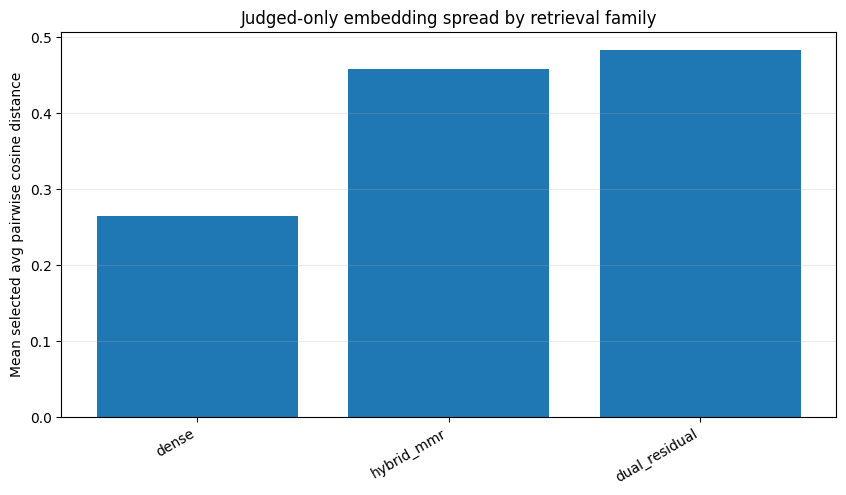

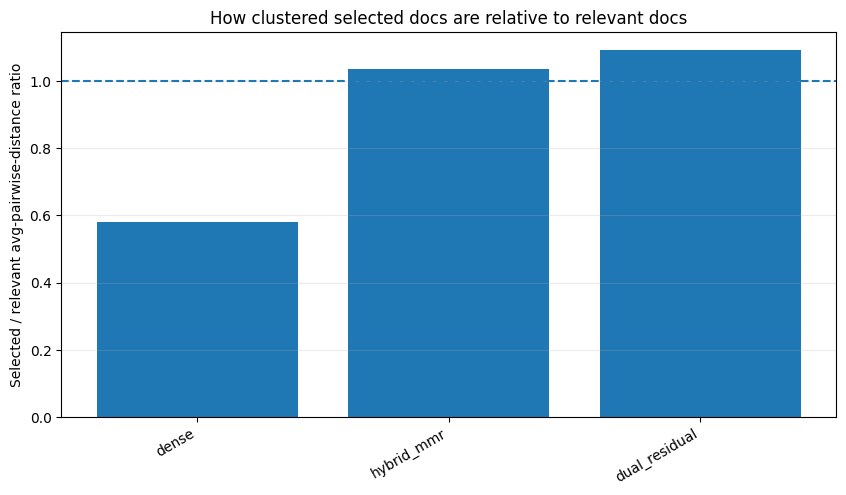

In [26]:
family_plot_df = (
    spread_df.groupby("family", as_index=False)[[
        "selected_avg_pairwise_dist",
        "selected_centroid_radius",
        "selected_vs_relevant_ratio",
        "selected_vs_grade3_ratio",
    ]]
    .mean()
    .sort_values("selected_avg_pairwise_dist", ascending=True)
)

plt.figure(figsize=(10, 5))
plt.bar(family_plot_df["family"], family_plot_df["selected_avg_pairwise_dist"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean selected avg pairwise cosine distance")
plt.title("Judged-only embedding spread by retrieval family")
plt.grid(axis="y", alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(family_plot_df["family"], family_plot_df["selected_vs_relevant_ratio"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Selected / relevant avg-pairwise-distance ratio")
plt.title("How clustered selected docs are relative to relevant docs")
plt.axhline(1.0, linestyle="--")
plt.grid(axis="y", alpha=0.25)
plt.show()

## Query-level visualization

This gives you a simple 2D PCA view for one query.

It overlays:
- all relevant docs
- grade-3 docs
- dense top-k
- one chosen MMR config
- one chosen dual residual config

You can swap the chosen methods below.

In [27]:
dense_method = "dense"

best_mmr_method = (
    spread_summary_df[spread_summary_df["family"] == "hybrid_mmr"]
    .sort_values("selected_avg_pairwise_dist", ascending=False)
    .iloc[0]["method"]
)

best_dual_method = (
    spread_summary_df[spread_summary_df["family"] == "dual_residual"]
    .sort_values("selected_avg_pairwise_dist", ascending=False)
    .iloc[0]["method"]
)

print("Chosen MMR method:", best_mmr_method)
print("Chosen dual residual method:", best_dual_method)

Chosen MMR method: mmr_a07_l05
Chosen dual residual method: dualres_a09_eta025_sd2_b05_r005_s01


In [28]:
# choose one representative method from each family
dense_method = "dense"

best_mmr_method = (
    spread_summary_df[spread_summary_df["family"] == "hybrid_mmr"]
    .sort_values("selected_avg_pairwise_dist", ascending=False)
    .iloc[0]["method"]
)

best_dual_method = (
    spread_summary_df[spread_summary_df["family"] == "dual_residual"]
    .sort_values("selected_avg_pairwise_dist", ascending=False)
    .iloc[0]["method"]
)

dense_q = spread_df[spread_df["method"] == dense_method][
    ["qid", "selected_avg_pairwise_dist"]
].rename(columns={"selected_avg_pairwise_dist": "dense_spread"})

mmr_q = spread_df[spread_df["method"] == best_mmr_method][
    ["qid", "selected_avg_pairwise_dist"]
].rename(columns={"selected_avg_pairwise_dist": "mmr_spread"})

dual_q = spread_df[spread_df["method"] == best_dual_method][
    ["qid", "selected_avg_pairwise_dist"]
].rename(columns={"selected_avg_pairwise_dist": "dual_spread"})

compare_df = dense_q.merge(mmr_q, on="qid").merge(dual_q, on="qid")
compare_df["dual_minus_dense"] = compare_df["dual_spread"] - compare_df["dense_spread"]
compare_df["mmr_minus_dense"] = compare_df["mmr_spread"] - compare_df["dense_spread"]

compare_df.sort_values("dual_minus_dense", ascending=False).head(10)

,qid,dense_spread,mmr_spread,dual_spread,dual_minus_dense,mmr_minus_dense
25,183378,0.077279,0.642809,0.577336,0.500057,0.565529
84,583468,0.066604,0.184927,0.563154,0.496550,0.118324
40,1113437,0.164318,0.675449,0.619397,0.455078,0.511130
12,1121402,0.171176,0.460796,0.614808,0.443632,0.289620
61,1132532,0.131246,0.564054,0.567685,0.436439,0.432808
26,1106007,0.102710,0.479634,0.538971,0.436261,0.376924
21,104861,0.098320,0.568735,0.513366,0.415046,0.470415
2,1063750,0.204368,0.568913,0.614120,0.409752,0.364545
94,938400,0.185641,0.561102,0.587013,0.401372,0.375461
16,451602,0.213469,0.607353,0.594503,0.381034,0.393884


In [29]:
interesting_queries = []

for qid in retrieval_df["qid"].unique():

    dense_selected = retrieval_df[
        (retrieval_df["qid"] == qid) & (retrieval_df["method"] == dense_method)
    ].iloc[0]["retrieved_doc_ids"]

    mmr_selected = retrieval_df[
        (retrieval_df["qid"] == qid) & (retrieval_df["method"] == best_mmr_method)
    ].iloc[0]["retrieved_doc_ids"]

    dual_selected = retrieval_df[
        (retrieval_df["qid"] == qid) & (retrieval_df["method"] == best_dual_method)
    ].iloc[0]["retrieved_doc_ids"]

    qrels = qrels_frozen[qid]

    dense_g3 = [d for d in dense_selected if qrels.get(d,0) == 3]
    mmr_g3 = [d for d in mmr_selected if qrels.get(d,0) == 3]
    dual_g3 = [d for d in dual_selected if qrels.get(d,0) == 3]

    if len(dense_g3) == 0 and len(mmr_g3) > 0 and len(dual_g3) > 0:
        interesting_queries.append(qid)

print("Found", len(interesting_queries), "queries")
interesting_queries[:10]

Found 3 queries


['1037798', '1133579', '405163']

In [30]:
# def spread_points(ids, query_text):
#     emb = np.vstack([doc_embeddings[doc_index[d]] for d in ids])

#     q = embed_query(query_text)
#     centroid = emb.mean(axis=0)

#     dist_to_query = cosine_distances(emb, q.reshape(1, -1)).flatten()
#     dist_to_centroid = cosine_distances(emb, centroid.reshape(1, -1)).flatten()

#     return dist_to_query, dist_to_centroid

# dense_x, dense_y = spread_points(dense_selected, viz_query)
# mmr_x, mmr_y = spread_points(mmr_selected, viz_query)
# dual_x, dual_y = spread_points(dual_selected, viz_query)

# all_x = np.concatenate([dense_x, mmr_x, dual_x])
# all_y = np.concatenate([dense_y, mmr_y, dual_y])

# x_min, x_max = all_x.min(), all_x.max()
# y_min, y_max = all_y.min(), all_y.max()

# pad_x = 0.05 * (x_max - x_min + 1e-12)
# pad_y = 0.05 * (y_max - y_min + 1e-12)

# def plot_spread_same_axes(x, y, label):
#     plt.figure(figsize=(6, 5))
#     plt.scatter(x, y, s=80)
#     plt.xlabel("distance to query")
#     plt.ylabel("distance to selection centroid")
#     plt.title(label)
#     plt.xlim(x_min - pad_x, x_max + pad_x)
#     plt.ylim(y_min - pad_y, y_max + pad_y)
#     plt.grid(alpha=0.25)
#     plt.show()

# plot_spread_same_axes(dense_x, dense_y, "dense")
# plot_spread_same_axes(mmr_x, mmr_y, "MMR")
# plot_spread_same_axes(dual_x, dual_y, "dual residual")

NameError: name 'viz_query' is not defined

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for ax, (x, y, label) in zip(
#     axes,
#     [
#         (dense_x, dense_y, "dense"),
#         (mmr_x, mmr_y, "MMR"),
#         (dual_x, dual_y, "dual residual"),
#     ]
# ):
#     ax.scatter(x, y, s=80)
#     ax.set_title(label)
#     ax.set_xlabel("distance to query")
#     ax.set_ylabel("distance to selection centroid")
#     ax.set_xlim(x_min - pad_x, x_max + pad_x)
#     ax.set_ylim(y_min - pad_y, y_max + pad_y)
#     ax.grid(alpha=0.25)

# plt.tight_layout()
# plt.show()

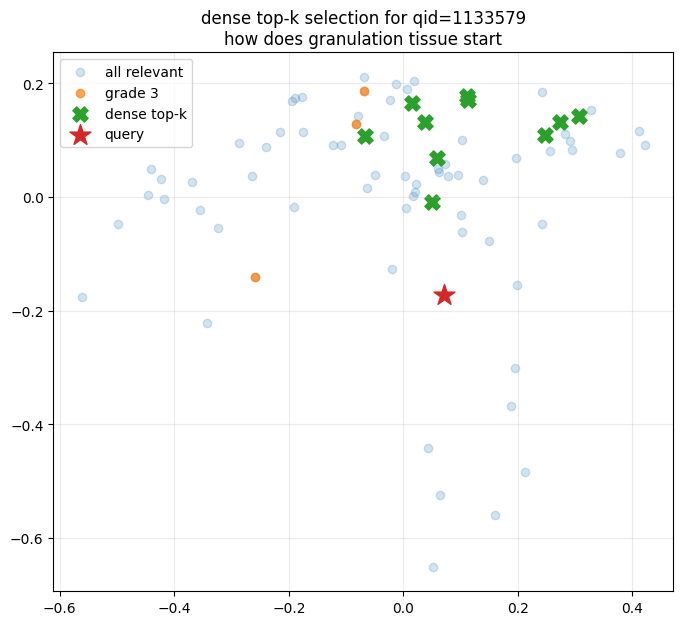

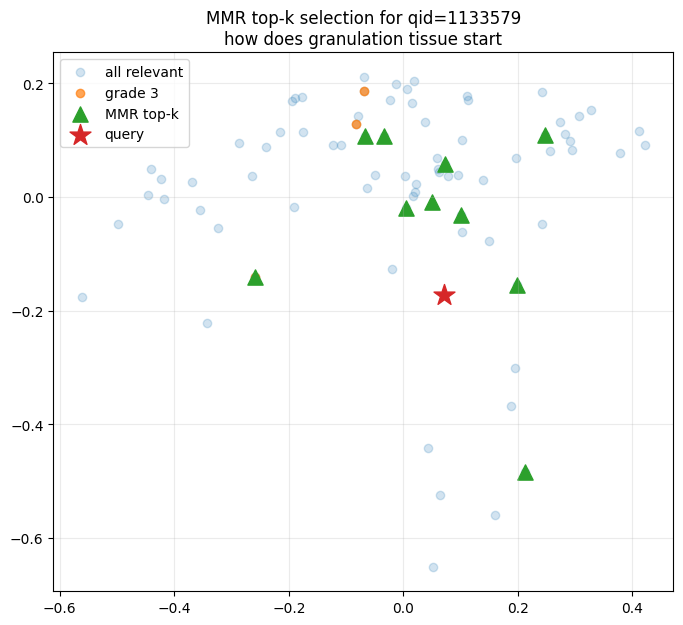

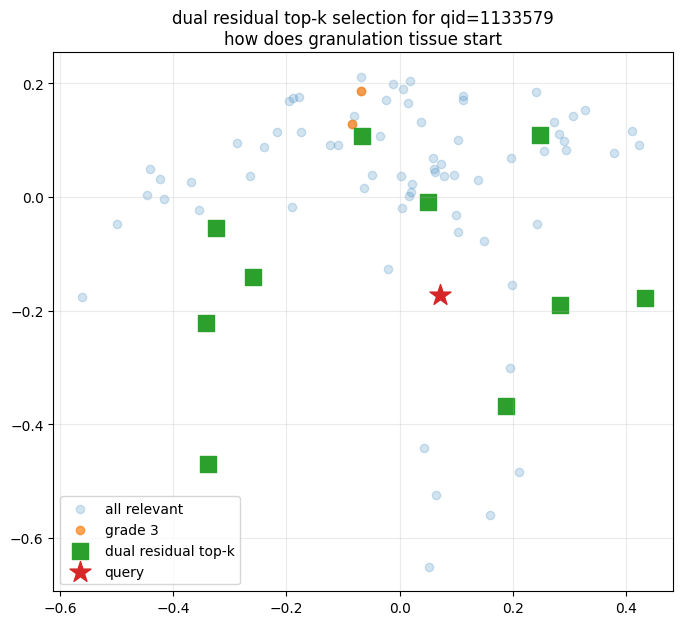

In [31]:
viz_qid = "1133579"
viz_query = queries_frozen[viz_qid]

rel_all, rel_g3 = relevant_doc_sets(viz_qid)

dense_selected = retrieval_df[
    (retrieval_df["qid"] == viz_qid) & (retrieval_df["method"] == dense_method)
].iloc[0]["retrieved_doc_ids"]

mmr_selected = retrieval_df[
    (retrieval_df["qid"] == viz_qid) & (retrieval_df["method"] == best_mmr_method)
].iloc[0]["retrieved_doc_ids"]

dual_selected = retrieval_df[
    (retrieval_df["qid"] == viz_qid) & (retrieval_df["method"] == best_dual_method)
].iloc[0]["retrieved_doc_ids"]

q_emb = embed_query(viz_query)

plot_doc_ids = sorted(set(rel_all) | set(dense_selected) | set(mmr_selected) | set(dual_selected))
plot_emb = np.vstack([doc_embeddings[doc_index[d]] for d in plot_doc_ids])
all_emb = np.vstack([plot_emb, q_emb.reshape(1, -1)])

pca = PCA(n_components=2, random_state=SEED)
all_xy = pca.fit_transform(all_emb)

plot_xy = all_xy[:-1]
query_xy = all_xy[-1]
xy_map = {doc_id: plot_xy[i] for i, doc_id in enumerate(plot_doc_ids)}

def plot_method_selection(selected_doc_ids, method_label, marker):
    plt.figure(figsize=(8, 7))

    rel_xy = np.vstack([xy_map[d] for d in rel_all]) if rel_all else np.zeros((0, 2))
    if len(rel_xy):
        plt.scatter(rel_xy[:, 0], rel_xy[:, 1], alpha=0.2, label="all relevant")

    g3_xy = np.vstack([xy_map[d] for d in rel_g3]) if rel_g3 else np.zeros((0, 2))
    if len(g3_xy):
        plt.scatter(g3_xy[:, 0], g3_xy[:, 1], alpha=0.7, label="grade 3")

    sel_xy = np.vstack([xy_map[d] for d in selected_doc_ids if d in xy_map])
    if len(sel_xy):
        plt.scatter(sel_xy[:, 0], sel_xy[:, 1], marker=marker, s=120, label=method_label)

    plt.scatter(query_xy[0], query_xy[1], marker="*", s=250, label="query")

    plt.title(f"{method_label} selection for qid={viz_qid}\n{viz_query}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

plot_method_selection(dense_selected, "dense top-k", "X")
plot_method_selection(mmr_selected, "MMR top-k", "^")
plot_method_selection(dual_selected, "dual residual top-k", "s")

NameError: name 'dense_x' is not defined

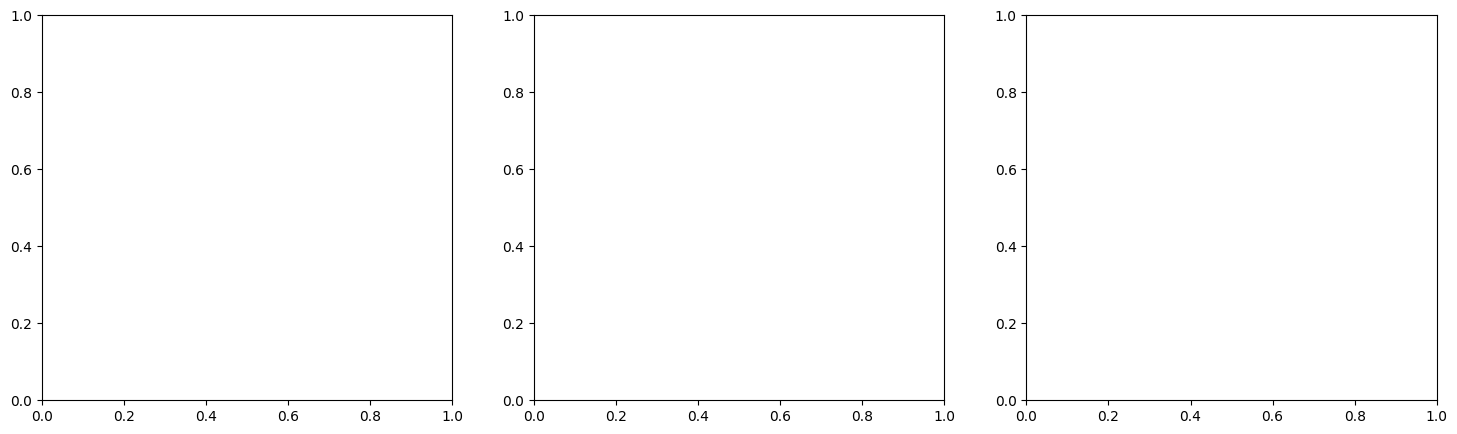

In [32]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for ax, (x, y, label) in zip(
#     axes,
#     [
#         (dense_x, dense_y, "dense"),
#         (mmr_x, mmr_y, "MMR"),
#         (dual_x, dual_y, "dual residual"),
#     ]
# ):
#     ax.scatter(x, y, s=80)
#     ax.set_title(label)
#     ax.set_xlabel("distance to query")
#     ax.set_ylabel("distance to selection centroid")
#     ax.set_xlim(x_min - pad_x, x_max + pad_x)
#     ax.set_ylim(y_min - pad_y, y_max + pad_y)
#     ax.grid(alpha=0.25)

# plt.tight_layout()
# plt.show()

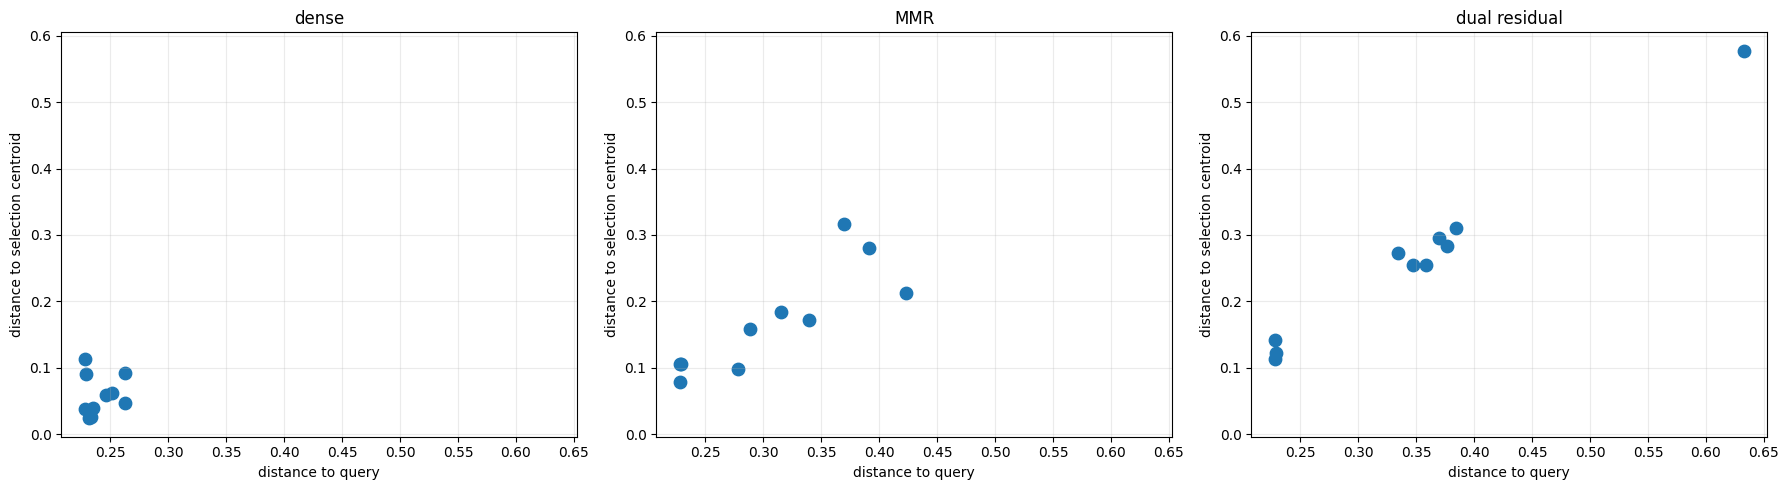

In [33]:
from sklearn.metrics.pairwise import cosine_distances

viz_qid = "1133579"
viz_query = queries_frozen[viz_qid]

dense_selected = retrieval_df[
    (retrieval_df["qid"] == viz_qid) & (retrieval_df["method"] == dense_method)
].iloc[0]["retrieved_doc_ids"]

mmr_selected = retrieval_df[
    (retrieval_df["qid"] == viz_qid) & (retrieval_df["method"] == best_mmr_method)
].iloc[0]["retrieved_doc_ids"]

dual_selected = retrieval_df[
    (retrieval_df["qid"] == viz_qid) & (retrieval_df["method"] == best_dual_method)
].iloc[0]["retrieved_doc_ids"]

def spread_points(ids, query_text):
    emb = np.vstack([doc_embeddings[doc_index[d]] for d in ids])
    q = embed_query(query_text)
    centroid = emb.mean(axis=0)

    dist_to_query = cosine_distances(emb, q.reshape(1, -1)).flatten()
    dist_to_centroid = cosine_distances(emb, centroid.reshape(1, -1)).flatten()
    return dist_to_query, dist_to_centroid

dense_x, dense_y = spread_points(dense_selected, viz_query)
mmr_x, mmr_y = spread_points(mmr_selected, viz_query)
dual_x, dual_y = spread_points(dual_selected, viz_query)

all_x = np.concatenate([dense_x, mmr_x, dual_x])
all_y = np.concatenate([dense_y, mmr_y, dual_y])

x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

pad_x = 0.05 * (x_max - x_min + 1e-12)
pad_y = 0.05 * (y_max - y_min + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x, y, label) in zip(
    axes,
    [
        (dense_x, dense_y, "dense"),
        (mmr_x, mmr_y, "MMR"),
        (dual_x, dual_y, "dual residual"),
    ]
):
    ax.scatter(x, y, s=80)
    ax.set_title(label)
    ax.set_xlabel("distance to query")
    ax.set_ylabel("distance to selection centroid")
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
x